# Case 1: 2D Groundwater Contaminant Transport with a PINN

This tutorial is designed for university students who are new to physics-informed neural
networks (PINNs). Starting from mass conservation, we will use a small neural network to
approximate contaminant concentration in a two-dimensional aquifer and validate the result
against an analytical solution.

**Learning objectives:** understand PDE, initial-condition, and boundary-condition losses;
use automatic differentiation; and interpret error maps and relative $L_2$ errors.

## 1. Physical problem

Consider a homogeneous aquifer measuring $200\,\mathrm{m}\times100\,\mathrm{m}$. A spill
produces a compact contaminant plume. Groundwater advects the plume toward the upper right,
while hydrodynamic dispersion broadens it and lowers its peak concentration.

Choose $L_c=100\,\mathrm{m}$ and $T_c=100\,\mathrm{day}$ as the characteristic length and
time. Define $x^*=x/L_c$, $y^*=y/L_c$, and $t^*=t/T_c$. After dropping the stars, the
computational domain is $[0,2]\times[0,1]\times[0,1]$. The code values $v_x=0.60$,
$v_y=0.15$, and $D=0.01$ correspond to $0.60\,\mathrm{m/day}$,
$0.15\,\mathrm{m/day}$, and $1.0\,\mathrm{m^2/day}$, respectively. The initial plume is
centred at $(45,35)\,\mathrm{m}$ and has a standard deviation of $10\,\mathrm{m}$.

In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Governing equation and analytical solution

Apply mass conservation to a small control volume: the increase in contaminant mass equals
the net inflow. The total flux consists of the advective flux $\mathbf{v}u$ and the Fickian
dispersive flux $-D\nabla u$, so

$$\frac{\partial u}{\partial t}+\nabla\cdot(\mathbf{v}u-D\nabla u)=0.$$

For constant velocity $\mathbf{v}=(v_x,v_y)$ and dispersion coefficient $D$, this becomes

$$u_t+v_xu_x+v_yu_y=D(u_{xx}+u_{yy}).$$

Let $q(t)=\sigma_0^2+2Dt$. The translating and spreading Gaussian plume

$$u(x,y,t)=\frac{\sigma_0^2}{q(t)}
\exp\!\left[-\frac{(x-x_0-v_xt)^2+(y-y_0-v_yt)^2}{2q(t)}\right]$$

is an analytical solution of the equation. The prefactor $\sigma_0^2/q(t)$ conserves total
mass in two dimensions. The analytical solution is used only for the initial and boundary
conditions and for post-training validation; **it is never used as a label at interior
collocation points**.

In [2]:
X_MAX, Y_MAX, T_MAX = 2.0, 1.0, 1.0
VX, VY = 0.60, 0.15
DIFFUSIVITY = 0.01
X0, Y0, SIGMA0 = 0.45, 0.35, 0.10

def exact_solution(xyt):
    '''Moving 2D Gaussian solution, evaluated at rows (x, y, t).'''
    x = xyt[:, 0:1]
    y = xyt[:, 1:2]
    t = xyt[:, 2:3]
    variance = SIGMA0**2 + 2.0 * DIFFUSIVITY * t
    radius2 = (x - X0 - VX*t)**2 + (y - Y0 - VY*t)**2
    return (SIGMA0**2 / variance) * torch.exp(-radius2 / (2.0*variance))

def exact_pde_residual(xyt):
    '''Autograd check that the analytical field obeys the PDE.'''
    if not xyt.requires_grad:
        xyt = xyt.detach().clone().requires_grad_(True)
    u = exact_solution(xyt)
    grad_u = torch.autograd.grad(
        u, xyt, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]
    u_x, u_y, u_t = grad_u[:, 0:1], grad_u[:, 1:2], grad_u[:, 2:3]
    u_xx = torch.autograd.grad(
        u_x, xyt, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0][:, 0:1]
    u_yy = torch.autograd.grad(
        u_y, xyt, grad_outputs=torch.ones_like(u_y), create_graph=True
    )[0][:, 1:2]
    return u_t + VX*u_x + VY*u_y - DIFFUSIVITY*(u_xx + u_yy)

## 3. GPU preference and CPU fallback

A free Colab GPU is not guaranteed to be available. The code performs a real CUDA tensor
operation before selecting the GPU. If that probe fails, it reports the reason and
immediately falls back to the CPU.

In [3]:
def select_device():
    '''Prefer CUDA only after a real allocation and arithmetic probe.'''
    if torch.cuda.is_available():
        try:
            probe = torch.empty(1, device="cuda")
            probe.fill_(2.0).square().sum().item()
            torch.cuda.synchronize()
            print(f"Using GPU: {torch.cuda.get_device_name(0)}")
            return torch.device("cuda")
        except Exception as error:
            try:
                torch.cuda.empty_cache()
            except Exception:
                pass
            print(f"CUDA initialization failed ({error}); switching to CPU.")
    else:
        print("No usable GPU is available in this runtime; using CPU.")
    return torch.device("cpu")

device = select_device()

Using GPU: Tesla T4


## 4. Sampling training points

We sample three sets: collocation points inside the space-time domain, points at the initial
time, and points on each of the four spatial boundaries.

In [4]:
def sample_points(config, device):
    '''Sample PDE, initial-condition, and four boundary point sets.'''
    n_pde = int(config["n_pde"])
    n_ic = int(config["n_ic"])
    n_edge = int(config["n_bc_each"])
    if min(n_pde, n_ic, n_edge) <= 0:
        raise ValueError("All sample counts must be positive integers.")

    pde = torch.rand(n_pde, 3, device=device)
    pde[:, 0] *= X_MAX
    pde[:, 1] *= Y_MAX
    pde[:, 2] *= T_MAX

    ic = torch.rand(n_ic, 3, device=device)
    ic[:, 0] *= X_MAX
    ic[:, 1] *= Y_MAX
    ic[:, 2] = 0.0

    def edge_points(axis, value):
        edge = torch.rand(n_edge, 3, device=device)
        edge[:, 0] *= X_MAX
        edge[:, 1] *= Y_MAX
        edge[:, 2] *= T_MAX
        edge[:, axis] = value
        return edge

    bc = torch.cat([
        edge_points(0, 0.0), edge_points(0, X_MAX),
        edge_points(1, 0.0), edge_points(1, Y_MAX),
    ], dim=0)
    points = {"pde": pde, "ic": ic, "bc": bc}

    for name, tensor in points.items():
        if tensor.ndim != 2 or tensor.shape[1] != 3:
            raise AssertionError(f"{name} must have shape (N, 3)")
        if not torch.isfinite(tensor).all():
            raise AssertionError(f"{name} contains non-finite values")
        inside = (
            (tensor[:, 0] >= 0) & (tensor[:, 0] <= X_MAX)
            & (tensor[:, 1] >= 0) & (tensor[:, 1] <= Y_MAX)
            & (tensor[:, 2] >= 0) & (tensor[:, 2] <= T_MAX)
        )
        if not inside.all():
            raise AssertionError(f"{name} contains out-of-domain points")
    if not torch.all(ic[:, 2] == 0.0):
        raise AssertionError("Initial points must satisfy t=0")
    on_boundary = (
        (bc[:, 0] == 0.0) | (bc[:, 0] == X_MAX)
        | (bc[:, 1] == 0.0) | (bc[:, 1] == Y_MAX)
    )
    if not on_boundary.all():
        raise AssertionError("Boundary points must lie on a spatial edge")
    return points

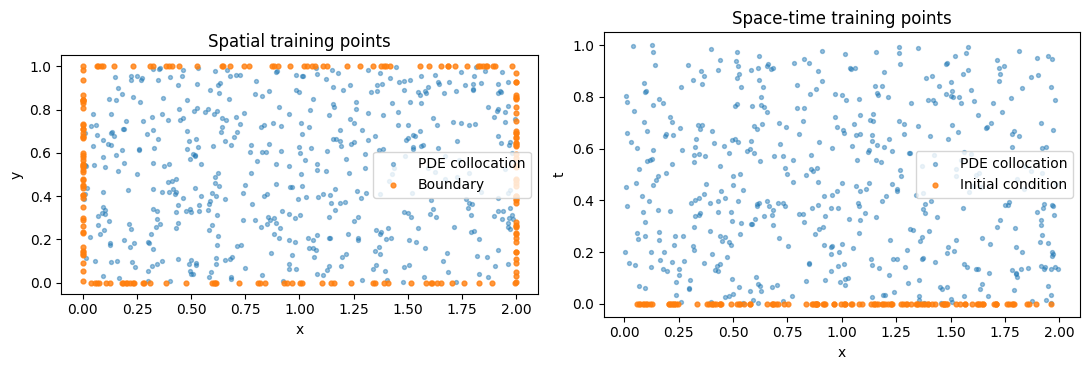

Maximum PDE residual of the analytical solution: 1.639e-07


In [5]:
preview_config = {"n_pde": 500, "n_ic": 120, "n_bc_each": 50}
preview = sample_points(preview_config, torch.device("cpu"))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(
    preview["pde"][:, 0], preview["pde"][:, 1],
    s=8, alpha=0.45, label="PDE collocation",
)
axes[0].scatter(
    preview["bc"][:, 0], preview["bc"][:, 1],
    s=12, alpha=0.8, label="Boundary",
)
axes[0].set(xlabel="x", ylabel="y", title="Spatial training points")
axes[0].set_aspect("equal")
axes[0].legend()

axes[1].scatter(
    preview["pde"][:, 0], preview["pde"][:, 2],
    s=8, alpha=0.45, label="PDE collocation",
)
axes[1].scatter(
    preview["ic"][:, 0], preview["ic"][:, 2],
    s=12, alpha=0.8, label="Initial condition",
)
axes[1].set(xlabel="x", ylabel="t", title="Space-time training points")
axes[1].legend()
plt.tight_layout()
plt.show()

check_xyt = torch.rand(128, 3, device=device)
check_xyt[:, 0] *= X_MAX
check_xyt.requires_grad_(True)
check_residual = exact_pde_residual(check_xyt)
print(f"Maximum PDE residual of the analytical solution: {check_residual.abs().max().item():.3e}")

## 5. PINN architecture and automatic differentiation

The network takes $(x,y,t)$ as input and predicts concentration $u$. PyTorch automatic
differentiation supplies the required first- and second-order derivatives.

To put all three inputs on comparable scales, they are linearly mapped to $[-1,1]^3$. The
fully connected network uses three hidden layers with 48 neurons per layer and `tanh`
activations. Substituting the network output into the governing equation gives the interior
residual

$$r_f=u_t+v_xu_x+v_yu_y-D(u_{xx}+u_{yy}).$$

In [6]:
def normalize_inputs(xyt):
    '''Map the rectangular space-time domain to [-1, 1]^3.'''
    lower = xyt.new_tensor([0.0, 0.0, 0.0])
    upper = xyt.new_tensor([X_MAX, Y_MAX, T_MAX])
    return 2.0 * (xyt - lower) / (upper - lower) - 1.0

class PINN(nn.Module):
    def __init__(self, hidden_width=48, hidden_layers=3):
        super().__init__()
        if hidden_width <= 0 or hidden_layers <= 0:
            raise ValueError("hidden_width and hidden_layers must be positive")
        layers = []
        in_features = 3
        for _ in range(hidden_layers):
            layer = nn.Linear(in_features, hidden_width)
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
            layers.extend([layer, nn.Tanh()])
            in_features = hidden_width
        output = nn.Linear(in_features, 1)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.network = nn.Sequential(*layers)

    def forward(self, xyt):
        return self.network(normalize_inputs(xyt))

def pde_residual(model, xyt):
    '''Return the advection-diffusion residual at interior points.'''
    xyt_grad = xyt.detach().clone().requires_grad_(True)
    u = model(xyt_grad)
    grad_u = torch.autograd.grad(
        u, xyt_grad, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]
    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]
    u_t = grad_u[:, 2:3]
    u_xx = torch.autograd.grad(
        u_x, xyt_grad, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0][:, 0:1]
    u_yy = torch.autograd.grad(
        u_y, xyt_grad, grad_outputs=torch.ones_like(u_y), create_graph=True
    )[0][:, 1:2]
    return u_t + VX*u_x + VY*u_y - DIFFUSIVITY*(u_xx + u_yy)

def compute_losses(model, points, weights=None):
    '''Compute PDE, initial, boundary, and weighted total MSE losses.'''
    weights = weights or {"pde": 1.0, "ic": 10.0, "bc": 10.0}
    required = {"pde", "ic", "bc"}
    if set(weights) != required:
        raise ValueError(f"weights must contain exactly {sorted(required)}")
    residual = pde_residual(model, points["pde"])
    loss_pde = torch.mean(residual.square())
    pred_ic = model(points["ic"])
    pred_bc = model(points["bc"])
    loss_ic = torch.mean((pred_ic - exact_solution(points["ic"])).square())
    loss_bc = torch.mean((pred_bc - exact_solution(points["bc"])).square())
    total = (
        weights["pde"]*loss_pde
        + weights["ic"]*loss_ic
        + weights["bc"]*loss_bc
    )
    return {"total": total, "pde": loss_pde, "ic": loss_ic, "bc": loss_bc}

## 6. Model training

`FAST_MODE=True` is suitable for a classroom demonstration. Set it to `False` for a longer,
higher-accuracy run.

Three mean-squared-error terms enforce the PDE, the initial concentration, and the four
spatial boundaries:

$$\mathcal{L}=w_f\,\mathrm{MSE}(r_f)
+w_i\,\mathrm{MSE}(u_\theta-u_{\mathrm{exact}})_{t=0}
+w_b\,\mathrm{MSE}(u_\theta-u_{\mathrm{exact}})_{\partial\Omega}.$$

The default weights are $(w_f,w_i,w_b)=(1,10,10)$. New points are sampled at every
iteration, so the loss may fluctuate from one step to the next. Focus on the overall trend
rather than expecting a decrease at every iteration.

In [7]:
FAST_MODE = True
FAST_CONFIG = dict(
    n_pde=1000, n_ic=256, n_bc_each=128,
    iterations=2000, learning_rate=1e-3, print_every=200,
)
ACCURATE_CONFIG = dict(
    n_pde=5000, n_ic=1000, n_bc_each=500,
    iterations=10000, learning_rate=1e-3, print_every=500,
)

def train_model(model, config, device):
    '''Train with fresh random collocation points at every Adam step.'''
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    history = {"total": [], "pde": [], "ic": [], "bc": []}
    weights = config.get("weights", {"pde": 1.0, "ic": 10.0, "bc": 10.0})
    started = time.perf_counter()

    for step in range(1, int(config["iterations"]) + 1):
        points = sample_points(config, device)
        losses = compute_losses(model, points, weights)
        if not all(torch.isfinite(value).item() for value in losses.values()):
            raise FloatingPointError(f"Non-finite loss at iteration {step}")
        optimizer.zero_grad(set_to_none=True)
        losses["total"].backward()
        optimizer.step()
        for name, value in losses.items():
            history[name].append(float(value.detach().cpu()))
        if step == 1 or step % int(config["print_every"]) == 0:
            elapsed = time.perf_counter() - started
            print(
                f"iteration {step:5d}/{config['iterations']} | "
                f"total={history['total'][-1]:.3e} | "
                f"PDE={history['pde'][-1]:.3e} | "
                f"IC={history['ic'][-1]:.3e} | "
                f"BC={history['bc'][-1]:.3e} | {elapsed:.1f} s"
            )
    return history

Mode: FAST_MODE (classroom demonstration)
Device: cuda; configuration: {'n_pde': 1000, 'n_ic': 256, 'n_bc_each': 128, 'iterations': 2000, 'learning_rate': 0.001, 'print_every': 200}
iteration     1/2000 | total=8.421e-01 | PDE=1.661e-01 | IC=5.358e-02 | BC=1.402e-02 | 0.5 s
iteration   200/2000 | total=6.362e-02 | PDE=3.164e-03 | IC=5.738e-03 | BC=3.069e-04 | 2.8 s
iteration   400/2000 | total=1.199e-01 | PDE=2.372e-03 | IC=1.136e-02 | BC=3.935e-04 | 5.4 s
iteration   600/2000 | total=1.054e-01 | PDE=2.199e-03 | IC=9.817e-03 | BC=5.063e-04 | 8.4 s
iteration   800/2000 | total=1.388e-01 | PDE=1.959e-03 | IC=1.292e-02 | BC=7.650e-04 | 10.6 s
iteration  1000/2000 | total=1.179e-01 | PDE=2.417e-03 | IC=1.118e-02 | BC=3.665e-04 | 12.9 s
iteration  1200/2000 | total=6.204e-02 | PDE=3.386e-03 | IC=5.583e-03 | BC=2.822e-04 | 15.2 s
iteration  1400/2000 | total=4.926e-02 | PDE=3.580e-03 | IC=4.375e-03 | BC=1.924e-04 | 17.9 s
iteration  1600/2000 | total=2.540e-02 | PDE=5.190e-03 | IC=1.853e-03 

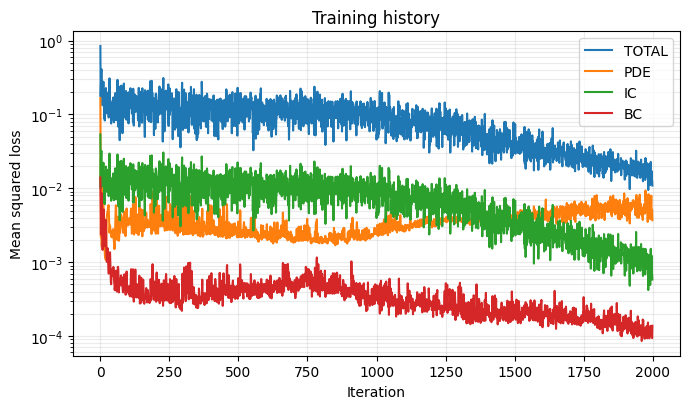

In [8]:
config = FAST_CONFIG.copy() if FAST_MODE else ACCURATE_CONFIG.copy()
mode_name = "FAST_MODE (classroom demonstration)" if FAST_MODE else "ACCURATE_MODE (higher accuracy)"
print(f"Mode: {mode_name}")
print(f"Device: {device}; configuration: {config}")

model = PINN(hidden_width=48, hidden_layers=3)
training_started = time.perf_counter()
history = train_model(model, config, device)
training_seconds = time.perf_counter() - training_started
print(f"Training completed in {training_seconds:.1f} s")

fig, ax = plt.subplots(figsize=(7, 4.2))
for name, values in history.items():
    ax.semilogy(values, label=name.upper())
ax.set(xlabel="Iteration", ylabel="Mean squared loss", title="Training history")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Results and error analysis

At $t=0,0.5,1$, compare the analytical solution, the PINN prediction, and the absolute error.
We also report the relative $L_2$ error on a held-out grid.

In [9]:
def relative_l2_error(prediction, truth):
    '''Return ||prediction-truth||_2 / ||truth||_2.'''
    prediction = torch.as_tensor(prediction)
    truth = torch.as_tensor(truth, device=prediction.device)
    denominator = torch.linalg.vector_norm(truth)
    if denominator.item() == 0.0:
        raise ValueError("truth must have a non-zero L2 norm")
    numerator = torch.linalg.vector_norm(prediction - truth)
    return float((numerator / denominator).detach().cpu())

def evaluate_grid(model, time_value, device, nx=161, ny=81):
    '''Evaluate the trained PINN and exact solution on a held-out grid.'''
    x = torch.linspace(0.0, X_MAX, nx)
    y = torch.linspace(0.0, Y_MAX, ny)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    tt = torch.full_like(xx, float(time_value))
    xyt_cpu = torch.stack([xx.reshape(-1), yy.reshape(-1), tt.reshape(-1)], dim=1)
    predictions = []
    model.eval()
    with torch.no_grad():
        for chunk in xyt_cpu.split(4096):
            predictions.append(model(chunk.to(device)).cpu())
        prediction = torch.cat(predictions, dim=0)
        truth = exact_solution(xyt_cpu)
    return (
        xx.numpy(), yy.numpy(),
        truth.reshape(ny, nx), prediction.reshape(ny, nx),
    )

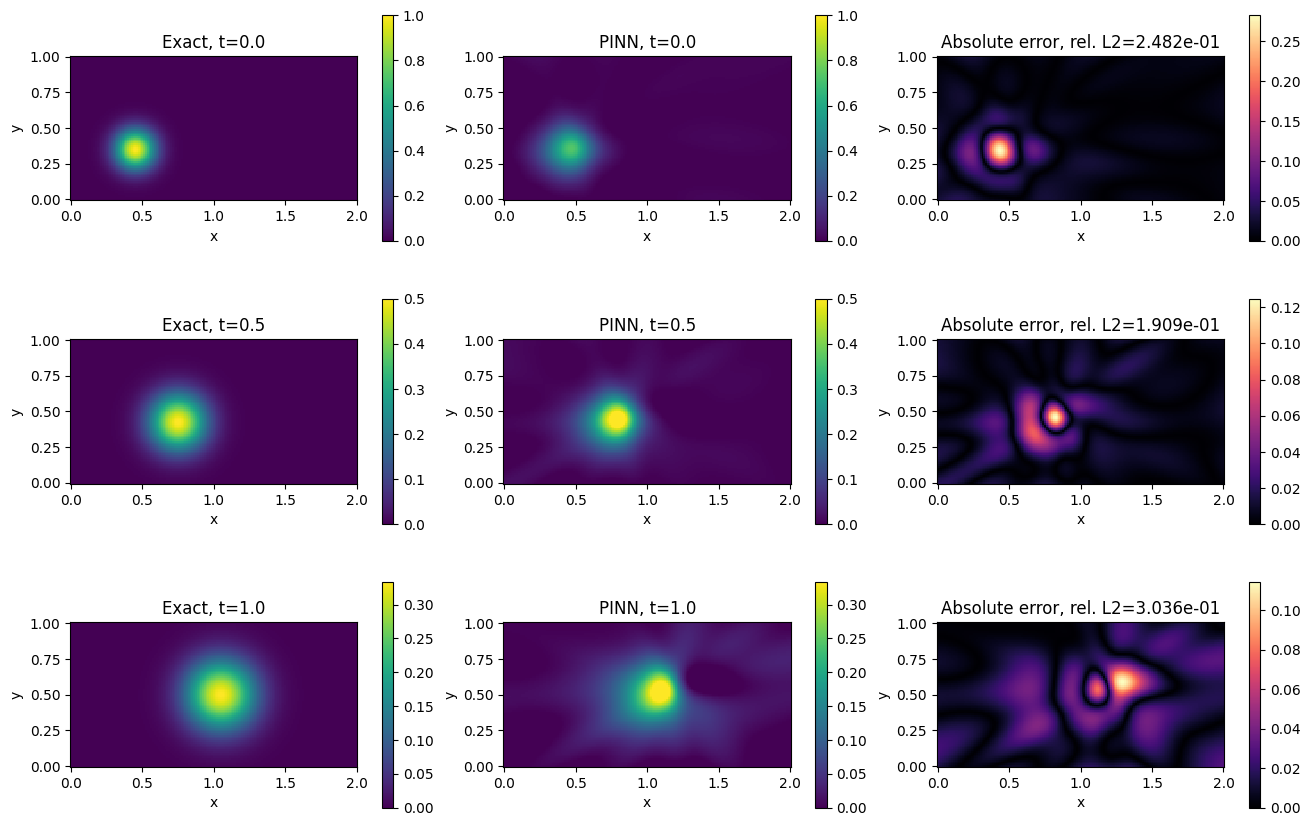


Held-out grid errors (exact interior values are evaluation-only):
 time    relative L2
  0.0    2.4815e-01
  0.5    1.9094e-01
  1.0    3.0356e-01


In [10]:
EVALUATION_TIMES = [0.0, 0.5, 1.0]
fig, axes = plt.subplots(
    len(EVALUATION_TIMES), 3, figsize=(13, 8.5), constrained_layout=True
)
error_rows = []

for row, time_value in enumerate(EVALUATION_TIMES):
    xx, yy, truth, prediction = evaluate_grid(model, time_value, device)
    absolute_error = torch.abs(prediction - truth)
    rel_error = relative_l2_error(prediction, truth)
    error_rows.append((time_value, rel_error))
    vmax = max(float(truth.max()), 1e-12)

    exact_plot = axes[row, 0].pcolormesh(
        xx, yy, truth.numpy(), shading="auto", vmin=0.0, vmax=vmax, cmap="viridis"
    )
    pred_plot = axes[row, 1].pcolormesh(
        xx, yy, prediction.numpy(), shading="auto", vmin=0.0, vmax=vmax, cmap="viridis"
    )
    error_plot = axes[row, 2].pcolormesh(
        xx, yy, absolute_error.numpy(), shading="auto", vmin=0.0, cmap="magma"
    )
    axes[row, 0].set_title(f"Exact, t={time_value:.1f}")
    axes[row, 1].set_title(f"PINN, t={time_value:.1f}")
    axes[row, 2].set_title(f"Absolute error, rel. L2={rel_error:.3e}")
    fig.colorbar(exact_plot, ax=axes[row, 0], shrink=0.82)
    fig.colorbar(pred_plot, ax=axes[row, 1], shrink=0.82)
    fig.colorbar(error_plot, ax=axes[row, 2], shrink=0.82)
    for ax in axes[row]:
        ax.set(xlabel="x", ylabel="y")
        ax.set_aspect("equal")

plt.show()
print()
print("Held-out grid errors (exact interior values are evaluation-only):")
print(" time    relative L2")
for time_value, rel_error in error_rows:
    print(f" {time_value:4.1f}    {rel_error:10.4e}")

## 8. Exercises and next steps

1. Change the groundwater-flow direction and predict how the plume trajectory changes.
2. Compare two dispersion coefficients and explain their effects on peak concentration and
   plume width.
3. Change the number of interior collocation points and compare accuracy with runtime.

The next case will move from linear transport to the nonlinear Buckley–Leverett fractional-
flow equation for water flooding, introducing a saturation front and shock-related PINN
training challenges.